## 1. Chargement des bibliothèques et les jeux de données

In [1]:
# Import des librairies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge,Lasso,ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import joblib

In [3]:
# Chargement des données
X_train = pd.read_csv("Xtrainmissing.csv").squeeze()
y_train = pd.read_csv("ytrain.csv", header=None).squeeze()[:-1]
print(len(y_train))
print(len(X_train))
X_test = pd.read_csv("Xtest.csv")

1000
1000


## 2. Exploration des données d’entraînement

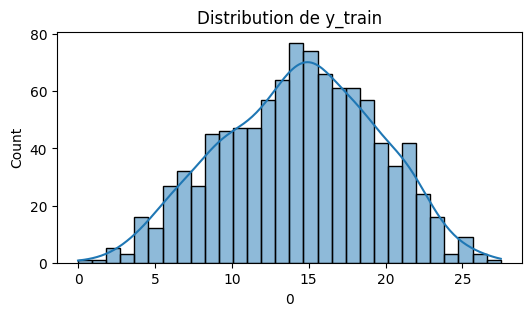

In [4]:
# Statistiques descriptives
plt.figure(figsize=(6,3))
sns.histplot(y_train, bins=30, kde=True)
plt.title('Distribution de y_train')
plt.show()

Pourcentage de valeurs manquantes:
64    1.8
19    1.7
95    1.6
91    1.6
78    1.6
97    1.5
84    1.5
93    1.5
41    1.4
87    1.4
dtype: float64


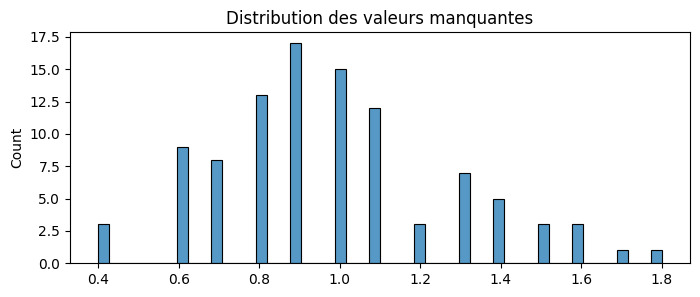

In [5]:
# Valeurs manquantes
mi_pct = X_train.isnull().mean()*100
print('Pourcentage de valeurs manquantes:')
print(mi_pct.sort_values(ascending=False).head(10))
plt.figure(figsize=(8,3))
sns.histplot(mi_pct, bins=50)
plt.title('Distribution des valeurs manquantes')
plt.show()

## 3. Gestion des valeurs manquantes

On va chercher les plus proches voisin permettant de completer les valeurs manquantes.
La méthode classique d'imputation par la moyenne ou la mediane sera testée.

In [6]:
imputers = {
    'mean': SimpleImputer(strategy='mean'),
    'median': SimpleImputer(strategy='median'),
    'knn_3': KNNImputer(n_neighbors=3),
    'knn_5': KNNImputer(n_neighbors=5),
    'knn_10': KNNImputer(n_neighbors=10)
}
models = {
    'LinearRegression': LinearRegression(),
    'Ridge_0.1': Ridge(alpha=0.1),
    'Ridge_1.0': Ridge(alpha=1.0),
    'Ridge_10.0': Ridge(alpha=10.0),
    'Lasso_0.01': Lasso(alpha=0.01, max_iter=10000),
    'Lasso_0.1': Lasso(alpha=0.1, max_iter=10000),
    'Lasso_1.0': Lasso(alpha=1.0, max_iter=10000),
    'ElasticNet_0.1_0.5': ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
    'ElasticNet_0.1_0.8': ElasticNet(alpha=0.1, l1_ratio=0.8, max_iter=10000)
}
results = {}
for imp_name, imputer in imputers.items():
    for mod_name, model in models.items():
        pipe = Pipeline([
            ('imputer', imputer),
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        cv_score = cross_val_score(pipe, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
        mse = -cv_score.mean()
        results[(imp_name, mod_name)] = mse
        print(f"Imputation: {imp_name}, Modèle: {mod_name}, MSE: {mse:.4f}")
best_combo = min(results, key=results.get)
print(f"Meilleure combinaison: Imputation={best_combo[0]}, Modèle={best_combo[1]}, MSE={results[best_combo]:.4f}")

Imputation: mean, Modèle: LinearRegression, MSE: 30.2459
Imputation: mean, Modèle: Ridge_0.1, MSE: 30.2445
Imputation: mean, Modèle: Ridge_1.0, MSE: 30.2315
Imputation: mean, Modèle: Ridge_10.0, MSE: 30.1056
Imputation: mean, Modèle: Lasso_0.01, MSE: 29.7662
Imputation: mean, Modèle: Lasso_0.1, MSE: 26.8878
Imputation: mean, Modèle: Lasso_1.0, MSE: 25.0489
Imputation: mean, Modèle: ElasticNet_0.1_0.5, MSE: 27.9140
Imputation: mean, Modèle: ElasticNet_0.1_0.8, MSE: 27.2651
Imputation: median, Modèle: LinearRegression, MSE: 30.2400
Imputation: median, Modèle: Ridge_0.1, MSE: 30.2386
Imputation: median, Modèle: Ridge_1.0, MSE: 30.2257
Imputation: median, Modèle: Ridge_10.0, MSE: 30.0998
Imputation: median, Modèle: Lasso_0.01, MSE: 29.7618
Imputation: median, Modèle: Lasso_0.1, MSE: 26.8864
Imputation: median, Modèle: Lasso_1.0, MSE: 25.0489
Imputation: median, Modèle: ElasticNet_0.1_0.5, MSE: 27.9113
Imputation: median, Modèle: ElasticNet_0.1_0.8, MSE: 27.2627
Imputation: knn_3, Modèle: L

**La meilleur méthode  d'imputation est celle basée sur la moyenne puis la regression lasso sera la mieux placée.**

## 4-Entrainemment du modèle

**Modèle Lasso (alpha=1.0) avec imputation sur la moyenne, entraînement puis prédiction sur le test.**

In [12]:
lasso_model = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=1.0, random_state=42, max_iter=10000))
])
lasso_model.fit(X_train, y_train.squeeze())
# Prédictions sur le test
y_pred_test_lasso = lasso_model.predict(X_test)

In [11]:
# Sauvegarde de prediction
df_pred_lasso = pd.DataFrame({'y_pred': y_pred_test_lasso})
df_pred_lasso.to_csv('ypred_lasso.csv', index=False)